[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kulinskij-tech/Synergetics/blob/main/syn_py/syn_08_synchronization.ipynb)


# 08. Synchronization and collective phase dynamics

_Graduate course: Introduction to Synergetics · English draft_

> **Guiding question:** How can weak coupling produce a macroscopic rhythm from heterogeneous oscillators?

**Notebook contract.** Run from top to bottom. All parameters are dimensionless unless stated otherwise. Explain every diagnostic you use; a visually attractive trajectory is not by itself evidence of self-organization.


## Learning outcomes

By the end of this module, you should be able to:

- explain how a compliant common support couples Huygens clocks and movable-base metronomes
- derive and test the locking condition for a reduced pair of phase oscillators
- derive the Kuramoto mean-field form
- compute and interpret the complex order parameter
- separate finite-size coherence from a collective transition


## Prerequisite bridge: phase reduction

A stable oscillator returns to the same closed orbit after one period $T$. Its phase $\theta\in[0,2\pi)$ labels position along that orbit and advances at natural frequency $\omega=2\pi/T$. Weak perturbations mainly shift phase because deviations transverse to the cycle decay.

Phase reduction discards amplitude transients and retains $\dot\theta_i=\omega_i+$ coupling. It is accurate for weak coupling and stable cycles, but can fail near amplitude instabilities, oscillator death, or strong forcing. The complex average $N^{-1}\sum_j e^{i\theta_j}$ is vector addition on the unit circle: random phases cancel, aligned phases reinforce.


## Huygens' clocks: synchronization through a moving support

In 1665 Christiaan Huygens reported the "odd sympathy" of two pendulum clocks carried by a common support: after transients their pendula maintained a nearly opposite phase. A modern classroom relative is a pair of self-sustained metronomes on a light platform that can recoil horizontally. Such metronomes commonly approach in-phase motion, although anti-phase motion can also be stable for other support, damping, and escapement parameters. **Synchronization is therefore not a mysterious direct attraction between pendula.** Each oscillator moves the support; the support acceleration perturbs both oscillators and transfers energy and momentum between them.

A minimal mechanical description, with pendulum angles $q_i$ and support displacement $x$, has the structure

$$ml^2\ddot q_i+b\dot q_i+mgl\sin q_i
=\tau_{\mathrm{esc},i}(q_i,\dot q_i)-ml\ddot x\cos q_i,$$

$$(M+2m)\ddot x+\Gamma\dot x+kx
=-ml\sum_{i=1}^2\left(\ddot q_i\cos q_i-\dot q_i^2\sin q_i\right).$$

The escapement torque replaces dissipated energy and creates a stable limit cycle; without that active element these would be decaying pendula, not clocks or metronomes. The course's local Mathematica archive (`metronome.nb`, `metronome0.nb`, and `Two Metronomes.nb`) develops this common-suspension model and diagnoses synchronization with relative phase. The accompanying videos provide an experimental check. The published notebook does not depend on those local files, so it remains portable to Colab.

Under weak coupling, amplitude deviations relax and the mechanical system reduces to a phase-difference equation

$$\dot\delta=\Delta\omega-2K\sin(\delta-\delta_0),\qquad \delta=\theta_2-\theta_1.$$

Here $\delta_0=0$ represents an in-phase attracting branch and $\delta_0=\pi$ an anti-phase branch. Phase locking exists when $|\Delta\omega|\leq 2K$, with stable lag $\delta^*=\delta_0+\sin^{-1}(\Delta\omega/2K)$. This reduced model cleanly predicts locking and phase slip, but it cannot determine $\delta_0$ from the apparatus: that requires the support and escapement mechanics above.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = np.random.default_rng(20260904)

def phase_locked_pair(delta0, delta_omega=0.08, K=0.12,
                      omega_mean=1.0, dt=0.02, duration=90.0):
    # Weak-coupling phase model for a self-sustained oscillator pair.
    t = np.arange(0.0, duration + dt, dt)
    theta = np.empty((2, t.size))
    theta[:, 0] = (0.0, -2.35)
    omega = np.array([omega_mean - delta_omega/2,
                      omega_mean + delta_omega/2])
    for n in range(t.size - 1):
        delta = theta[1, n] - theta[0, n]
        interaction = K*np.sin(delta - delta0)
        theta[:, n + 1] = theta[:, n] + dt*np.array([
            omega[0] + interaction,
            omega[1] - interaction,
        ])
    wrapped_delta = np.angle(np.exp(1j*(theta[1] - theta[0])))
    return t, theta, wrapped_delta

cases = [(0.0, "in-phase branch"), (np.pi, "anti-phase branch")]
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex="col")
for col, (delta0, label) in enumerate(cases):
    t, theta, delta = phase_locked_pair(delta0)
    tail = t > 70
    axes[0, col].plot(t[tail], np.cos(theta[0, tail]), label=r"$\cos\theta_1$")
    axes[0, col].plot(t[tail], np.cos(theta[1, tail]), label=r"$\cos\theta_2$", alpha=0.8)
    axes[0, col].set_title(label)
    axes[0, col].set_ylabel("oscillator signal")
    axes[0, col].legend()
    target = np.angle(np.exp(1j*(delta0 + np.arcsin(0.08/(2*0.12)))))
    axes[1, col].plot(t, delta)
    axes[1, col].axhline(target, color="k", ls="--", label=fr"$\delta^*={target:.2f}$")
    axes[1, col].set(xlabel="time", ylabel="wrapped phase difference")
    axes[1, col].legend()
plt.suptitle("Locking selected by the coupling branch")
plt.tight_layout()
plt.show()


## Conservative pendulums and self-sustained metronomes: coupling is not yet phase capture

Huygens' clocks contain escapements that compensate energy losses. The essential distinction is between **conservative motion** and **self-sustained motion with energy input and dissipation**, rather than pendulum versus metronome geometry. Compare the same two identical pendulums and translating bar with identical initial conditions, changing only the internal torque.

Two point bobs of mass $m$ and length $L$ hang from a rigid bar of mass $M$. The bar translates horizontally without friction; ideal constraints prevent vertical motion and rotation and do no work. Use dimensionless variables $\tau=t\sqrt{g/L}$, $x=X/L$, and $R=M/m$. With zero horizontal momentum and the **horizontal center of mass** fixed,

$$x=-\frac{\sin\theta_1+\sin\theta_2}{R+2}.$$

Eliminating the bar coordinate gives

$$\sum_{j=1}^{2}\left[\delta_{ij}-\frac{\cos\theta_i\cos\theta_j}{R+2}\right]\theta_j''=-\sin\theta_i-\frac{\cos\theta_i}{R+2}\sum_{j=1}^{2}\sin\theta_j(\theta_j')^2+q_i.$$

For conservative pendulums $q_i=0$. For a smooth escapement analogue use $q_i=\mu[1-(\theta_i/a)^2]\theta_i'$: energy is supplied at small amplitudes and removed at large amplitudes. This is a self-sustained pendulum model, not an exact model of a particular metronome. Masses, geometry and initial conditions are identical in both cases.

Mechanical energy in units of $mgL$ is

$$\mathcal E=\frac12\left[(\theta_1')^2+(\theta_2')^2-\frac{(\cos\theta_1\theta_1'+\cos\theta_2\theta_2')^2}{R+2}\right]+2-\cos\theta_1-\cos\theta_2.$$

It is conserved for $q_i=0$; otherwise $\mathcal E'=\sum_i q_i\theta_i'$. The small-angle normal-mode frequencies are $\Omega_{\mathrm{anti}}=1$ and $\Omega_{\mathrm{in}}=\sqrt{1+2/R}$. The in-phase mode drives bar recoil, while the anti-phase mode cancels the horizontal forces and leaves the bar at rest. Superposed modes produce beats; a heavier bar reduces the frequency splitting. Exactly symmetric initial conditions give synchronized motions, but these are **not attracting states** of the conservative system. Nonlinear conservative motion can also have regions of bounded relative phase; phase coordination alone does not establish attraction. This ideal constrained conservative setup is not a completely isolated freely falling assembly.

For visualization use the geometric diagnostic $\phi_i=\operatorname{atan2}(-\theta_i',\theta_i)$ and $\Delta\phi=\arccos[\cos(\phi_1-\phi_2)]$. It is useful for small oscillations but is not an exact isochron phase and becomes ill-defined near vanishing amplitude. Zero degrees means motion together; 180 degrees means opposite phases. Evidence for attracting synchronization requires convergence of relative-phase behavior from different initial conditions, not just one specially prepared synchronized trajectory.


In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display


def huygens_rhs(y, R, driven=False, mu=0.15, a=0.15):
    """Dimensionless mechanics; eliminate bar position using momentum."""
    p, q, u, v = y
    c, d = math.cos(p), math.cos(q)
    sp, sq = math.sin(p), math.sin(q)
    S = (sp*u*u + sq*v*v)/(R+2)
    b1, b2 = -sp-c*S, -sq-d*S
    if driven:
        b1 += mu*(1-(p/a)**2)*u
        b2 += mu*(1-(q/a)**2)*v
    A, B, D = 1-c*c/(R+2), -c*d/(R+2), 1-d*d/(R+2)
    determinant = A*D-B*B
    return (u, v, (D*b1-B*b2)/determinant,
            (A*b2-B*b1)/determinant)


def huygens_integrate(R=10.0, initial="mixed", driven=False,
                      duration=600.0, dt=0.01):
    """RK4; energy conservation is checked independently, not imposed."""
    if not np.isfinite(R) or R <= 0 or dt <= 0 or duration <= 0:
        raise ValueError("Require R > 0, dt > 0 and duration > 0.")
    presets = {"in": (.22, .22, 0., 0.),
               "anti": (.22, -.22, 0., 0.),
               "mixed": (.22, -.08, 0., .65)}
    y = presets[initial]
    steps = int(round(duration/dt))
    stride = max(1, int(round(.05/dt)))
    times, states = [], []
    for n in range(steps+1):
        if n % stride == 0 or n == steps:
            times.append(n*dt)
            states.append(y)
        if n == steps:
            break
        k1 = huygens_rhs(y, R, driven)
        k2 = huygens_rhs(tuple(z+dt*k/2 for z, k in zip(y, k1)), R, driven)
        k3 = huygens_rhs(tuple(z+dt*k/2 for z, k in zip(y, k2)), R, driven)
        k4 = huygens_rhs(tuple(z+dt*k for z, k in zip(y, k3)), R, driven)
        y = tuple(z+dt*(b+2*c+2*d+e)/6
                  for z, b, c, d, e in zip(y, k1, k2, k3, k4))
    t, y = np.asarray(times), np.asarray(states)
    angles, velocities = y[:, :2], y[:, 2:]
    cosine = np.cos(angles)
    x = -np.sin(angles).sum(axis=1)/(R+2)
    xdot = -(cosine*velocities).sum(axis=1)/(R+2)
    energy = .5*(np.sum(velocities**2, axis=1)
                 - np.sum(cosine*velocities, axis=1)**2/(R+2))
    energy += np.sum(1-np.cos(angles), axis=1)
    phi = np.arctan2(-velocities, angles)
    phase_gap = np.degrees(np.arccos(np.clip(np.cos(phi[:, 0]-phi[:, 1]), -1, 1)))
    return dict(t=t, y=y, x=x, xdot=xdot, energy=energy, phase_gap=phase_gap,
                R=R, driven=driven)


def huygens_comparison(R=10.0, initial="mixed", duration=600.0):
    cases = [huygens_integrate(R, initial, driven, duration)
             for driven in (False, True)]
    fig, axes = plt.subplots(3, 2, figsize=(12, 9), constrained_layout=True)
    names = ["Conservative pendulums", "Self-sustained pendulums"]
    for col, (result, name) in enumerate(zip(cases, names)):
        t, y = result["t"], result["y"]
        for j, style in enumerate(("-", "--")):
            axes[0, col].plot(t, y[:, j], style, label=f"Pendulum {j+1}")
        axes[0, col].set(xlim=(0, 12), ylabel="Angle (rad)", title=name)
        axes[0, col].legend()
        axes[1, col].plot(t, result["phase_gap"])
        axes[1, col].set(ylim=(-5, 185), yticks=[0, 90, 180],
                         ylabel="Phase separation (deg)")
        axes[2, col].plot(t, result["energy"]/result["energy"][0])
        axes[2, col].set(ylabel="Energy / initial energy", ylim=(0, 1.2))
        for row in range(3):
            axes[row, col].set_xlabel(r"Time $\tau=t\sqrt{g/L}$")
    fig.suptitle(f"Identical initial conditions; M/m = {R:g}")
    plt.show()
    error = np.max(np.abs(cases[0]["energy"]/cases[0]["energy"][0]-1))
    print(f"Maximum relative conservative energy error: {error:.2e}")
    return cases


def huygens_animation(cases, start=0.0, window=12.0):
    """Simultaneous comparison in the horizontal center-of-mass frame."""
    last_time = min(case["t"][-1] for case in cases)
    start = float(np.clip(start, 0, max(0, last_time-window)))
    frames = np.arange(start, min(start+window, last_time), .1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
    artists = []
    for ax, name in zip(axes, ("Conservative", "Self-sustained")):
        ax.set(xlim=(-1.8, 1.8), ylim=(-1.3, .4), aspect="equal", title=name,
               xlabel="x / L", ylabel="y / L")
        ax.axvline(0, color="0.6", linestyle=":", label="Horizontal COM")
        bar, = ax.plot([], [], color="0.4", lw=5)
        rods = [ax.plot([], [], style, lw=2)[0] for style in ("-", "--")]
        bobs = [ax.plot([], [], "o", color=rod.get_color(), ms=9)[0] for rod in rods]
        text = ax.text(.02, .92, "", transform=ax.transAxes)
        artists.append((bar, rods, bobs, text))

    def update(tau):
        updated = []
        for case, (bar, rods, bobs, text) in zip(cases, artists):
            # Linear interpolation of the saved states keeps playback smooth.
            state = [np.interp(tau, case["t"], case["y"][:, j]) for j in range(4)]
            x = -(math.sin(state[0])+math.sin(state[1]))/(case["R"]+2)
            bar.set_data([x-1.25, x+1.25], [0, 0])
            for j in range(2):
                pivot = x+(-.65 if j == 0 else .65)
                bx, by = pivot+math.sin(state[j]), -math.cos(state[j])
                rods[j].set_data([pivot, bx], [0, by])
                bobs[j].set_data([bx], [by])
            text.set_text(f"τ = {tau:.1f}")
            updated.extend([bar, *rods, *bobs, text])
        return updated

    animation = FuncAnimation(fig, update, frames=frames, interval=100,
                              blit=False, repeat=False)
    html = HTML(animation.to_jshtml(default_mode="once"))
    plt.close(fig)
    return html


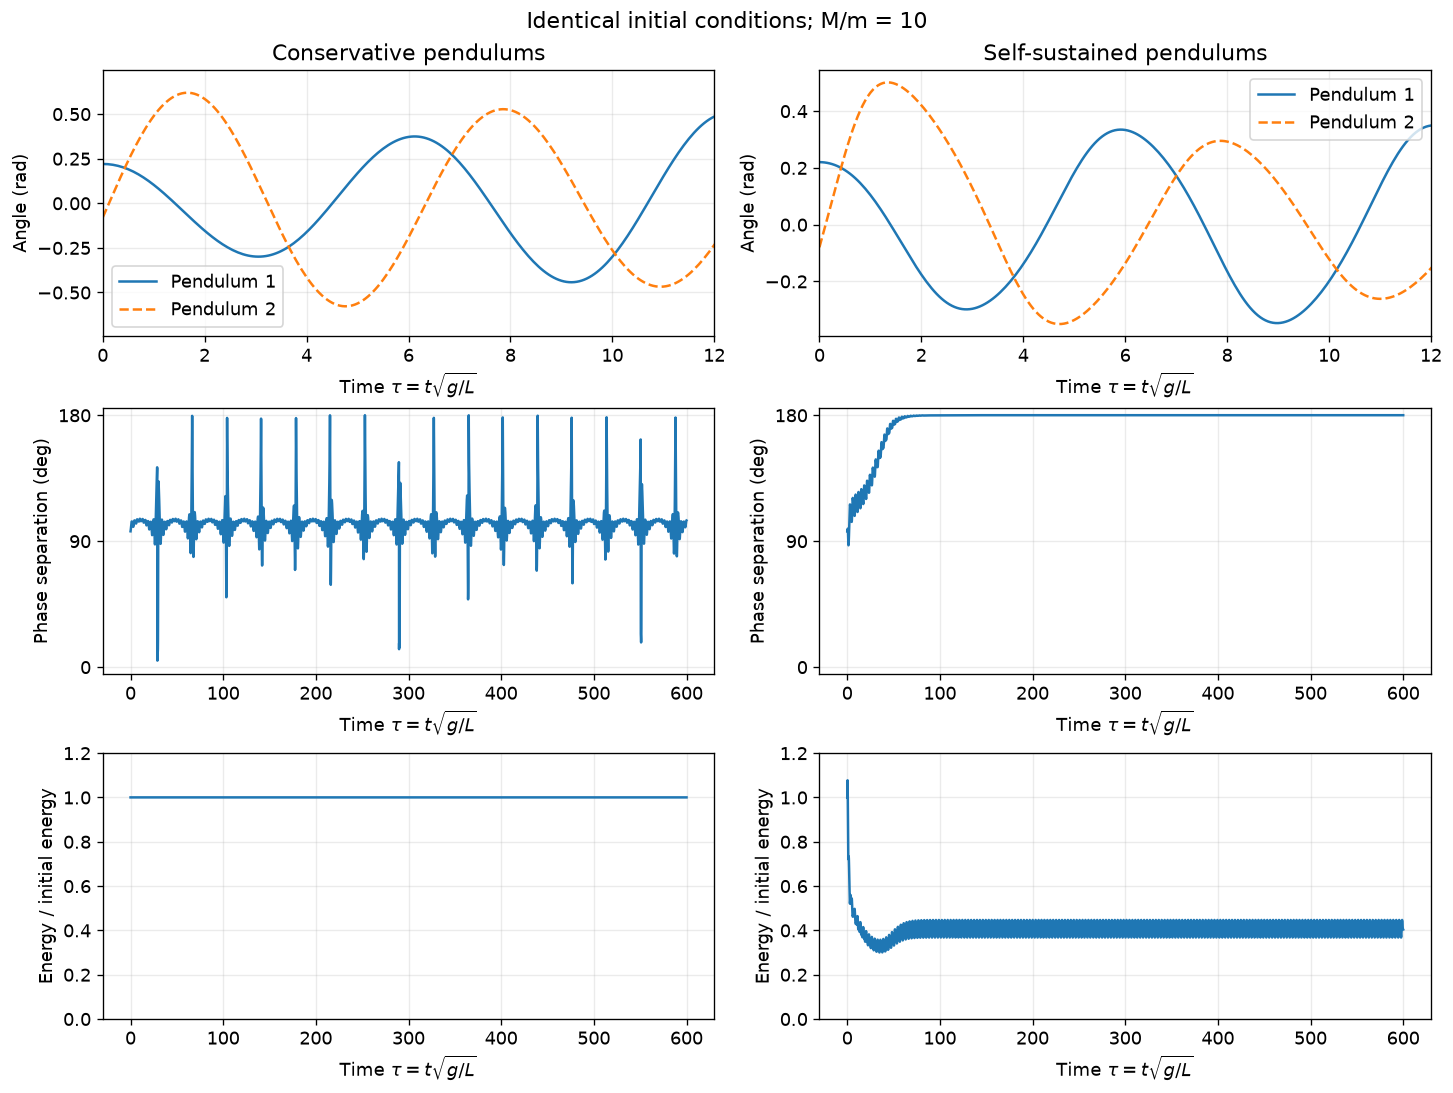

Maximum relative conservative energy error: 9.54e-10


In [ ]:
# Change M_over_m: 1, 10, 100, 1000; initial: mixed, in, anti.
M_over_m = 10.0
initial = "mixed"
pendulum_cases = huygens_comparison(M_over_m, initial)


### Animation and interpretation

Change `start` from `0` to `500` to compare initial and late motion. Both cases are shown at the same time. Conservative mechanical energy remains constant; the self-sustaining torque exchanges energy with the drive. With `M_over_m=10` and `initial="mixed"`, this driven model approaches anti-phase motion; this is not universal metronome behavior. Repeat with several nearby unequal initial states by editing the `mixed` preset. Compare late phase variation to distinguish an attracting state from beats or a specially prepared synchronized trajectory.


In [ ]:
display(huygens_animation(pendulum_cases, start=500.0))


<HTML animation>

## Kuramoto order parameter

The globally coupled phase model is

$$\dot\theta_i=\omega_i+\frac{K}{N}\sum_j\sin(\theta_j-\theta_i).$$

Define $Z=re^{i\psi}=N^{-1}\sum_j e^{i\theta_j}$. Then

$$\dot\theta_i=\omega_i+Kr\sin(\psi-\theta_i).$$

The many-body interaction is encoded by the collective field $Z$, a particularly clean example of circular causality: phases generate the order parameter, which in turn drives each phase. For a symmetric unimodal frequency density $g$, the infinite-population threshold is $K_c=2/[\pi g(0)]$.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = np.random.default_rng(20260904)

def kuramoto(K, omega, theta0, dt=0.03, steps=3500, burn=1500):
    theta = theta0.copy()
    r_history = []
    for n in range(steps):
        Z = np.mean(np.exp(1j*theta))
        theta += dt*(omega + K*np.abs(Z)*np.sin(np.angle(Z)-theta))
        if n >= burn:
            r_history.append(abs(np.mean(np.exp(1j*theta))))
    return np.mean(r_history), np.std(r_history), theta

N = 400
omega = rng.normal(0, 1, N)
theta0 = rng.uniform(0, 2*np.pi, N)
K_values = np.linspace(0, 4, 25)
stats = np.array([kuramoto(K, omega, theta0)[:2] for K in K_values])
Kc_theory = 2/(np.pi*(1/np.sqrt(2*np.pi)))

plt.errorbar(K_values, stats[:, 0], yerr=stats[:, 1], marker="o", ms=4, capsize=2)
plt.axvline(Kc_theory, color="k", ls="--", label=fr"$K_c={Kc_theory:.2f}$")
plt.xlabel("coupling K")
plt.ylabel("time-averaged coherence r")
plt.title("Finite Kuramoto ensemble")
plt.legend()
plt.show()


## Assessed exercise

Part A: scan detuning $\Delta\omega$ and coupling $K$ for the Huygens/metronome phase model. Classify locking by the long-time drift of $\delta$, map the boundary, and compare it with $|\Delta\omega|=2K$. Explain why this calculation alone cannot decide whether a real support selects in-phase or anti-phase motion. Part B: repeat the Kuramoto sweep for $N=100,400,1600$ using independent frequency samples. Estimate the finite-size baseline below threshold, define an operational $K_c(N)$, and extrapolate cautiously toward the theoretical value.

Your submission must include a claim, the mathematical or physical reason for it, numerical evidence, and one limitation.


## Reading and attribution

**Local course reading:** Kuramoto, *Chemical Oscillations, Waves, and Turbulence*; Mikhailov, *Foundations of Synergetics I*, oscillatory media. The instructor archive adds mechanical derivations and experiments in `metronome.nb`, `metronome0.nb`, `Two Metronomes.nb`, `synchro1.mp4`, and `synchro2.mp4`.

**Verified web reading:**
- [Physics World: The secret of the synchronized pendulums](https://physicsworld.com/a/the-secret-of-the-synchronized-pendulums/)
- [Pantaleone: Synchronization of metronomes](https://doi.org/10.1119/1.1501118)
- [Bennett et al.: Huygens's clocks](https://doi.org/10.1098/rspa.2001.0888)
- [Oliveira and Melo: Huygens synchronization of two clocks](https://doi.org/10.1038/srep11548)
- [Kuramoto's Chemical Oscillations, Waves, and Turbulence](https://doi.org/10.1007/978-3-642-69689-3)

The local books are course-provided sources. Web links are supplementary and were verified on 2026-09-04.
